In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "../..")
from data.preprocess.luts import stat_vars_dict

In [ ]:
seg_shp = "/beegfs/CMIP6/jdpaul3/hydroviz_data/gis/xwalk/seg_h8_outlet_stats_simplified.shp"
seg = gpd.read_file(seg_shp)
seg = seg[["seg_id_nat", "geometry"]].copy()

In [8]:
# define a tmp_dir variable to store unzipped files
tmp_dir = "/home/jdpaul3/scratch/hydroviz_uncertainty_analysis"

# create if it doesn't exist
if not os.path.exists(tmp_dir):
    os.makedirs(tmp_dir)

# unzip the files
zip_files = ["data_release/Future_KS.zip", "data_release/Historical_KS.zip"]

for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(tmp_dir)

# print the unzipped directories and the files they contain
# while listing the files
ks_files = []
for root, dirs, files in os.walk(tmp_dir):
    print(f"Directory: {root}")
    for file in files:
        print(f"  - {file}")
        if file.endswith(".csv"):
            ks_files.append(os.path.join(root, file))


Directory: /home/jdpaul3/scratch/hydroviz_uncertainty_analysis
Directory: /home/jdpaul3/scratch/hydroviz_uncertainty_analysis/Future_KS
  - dynamic_KSFutureSig_rcp45_r1i1p1_2016_2045_1976_2005_diff.csv
  - dynamic_KSFutureSig_rcp45_r1i1p1_2046_2075_1976_2005_diff.csv
  - dynamic_KSFutureSig_rcp45_r1i1p1_2071_2100_1976_2005_diff.csv
  - dynamic_KSFutureSig_rcp85_r1i1p1_2016_2045_1976_2005_diff.csv
  - dynamic_KSFutureSig_rcp85_r1i1p1_2046_2075_1976_2005_diff.csv
  - dynamic_KSFutureSig_rcp85_r1i1p1_2071_2100_1976_2005_diff.csv
  - static_KSFutureSig_rcp45_r1i1p1_2016_2045_1976_2005_diff.csv
  - static_KSFutureSig_rcp45_r1i1p1_2046_2075_1976_2005_diff.csv
  - static_KSFutureSig_rcp45_r1i1p1_2071_2100_1976_2005_diff.csv
  - static_KSFutureSig_rcp85_r1i1p1_2016_2045_1976_2005_diff.csv
  - static_KSFutureSig_rcp85_r1i1p1_2046_2075_1976_2005_diff.csv
  - static_KSFutureSig_rcp85_r1i1p1_2071_2100_1976_2005_diff.csv
Directory: /home/jdpaul3/scratch/hydroviz_uncertainty_analysis/Historical_KS
 

In [6]:
stat_vars_dict

{'dh1': {'category': 'duration',
  'code_base': 'mhit',
  'difference_method': 'ratio',
  'statistic_description': 'Annual maximum daily flow. Compute the maximum of a 1-day moving average flow for each year. DH1 is the mean of these values (cubic feet per second - temporal).',
  'units': 'cfs'},
 'dh2': {'category': 'duration',
  'code_base': 'mhit',
  'difference_method': 'ratio',
  'statistic_description': 'Annual maximum of 3-day moving average flows. Compute the maximum of a 3-day moving average flow for each year. DH2 is the mean of these values (cubic feet per second - temporal).',
  'units': 'cfs'},
 'dh3': {'category': 'duration',
  'code_base': 'mhit',
  'difference_method': 'ratio',
  'statistic_description': 'Annual maximum of 7-day moving average flows. Compute the maximum of a 7-day moving average flow for each year. DH3 is the mean of these values (cubic feet per second - temporal).',
  'units': 'cfs'},
 'dh4': {'category': 'duration',
  'code_base': 'mhit',
  'differenc

In [11]:
# get ma12 thru ma23 (monthly flows) for each stream segment
# in the historical KS test
print(ks_files[-1])

/home/jdpaul3/scratch/hydroviz_uncertainty_analysis/Historical_KS/static_KSHistSig_historical_r1i1p1_1976_2005_1976_2005_diff.csv


In [23]:
stats = ['ma12', 'ma13', 'ma14', 'ma15', 'ma16', 'ma17',
       'ma18', 'ma19', 'ma20', 'ma21', 'ma22', 'ma23']
df = pd.read_csv(ks_files[-1], usecols=stats + ['seg_id'])

# join with seg to get stats in gdf
gdf = seg.merge(df, left_on="seg_id_nat", right_on="seg_id")

In [26]:
gdf

,seg_id_nat,geometry,seg_id,ma12,ma13,ma14,ma15,ma16,ma17,ma18,ma19,ma20,ma21,ma22,ma23
0,1,"LINESTRING (2101948.624 2876678.641, 2100975.3...",1,12.0,12.0,13.0,12.0,13.0,13.0,13.0,12.0,13.0,8.0,13.0,13.0
1,2,"LINESTRING (2167789.031 2829021.852, 2167100.0...",2,12.0,13.0,13.0,13.0,13.0,13.0,12.0,11.0,13.0,13.0,13.0,5.0
2,3,"LINESTRING (2131936.492 2865675.020, 2133990.7...",3,13.0,13.0,13.0,13.0,13.0,13.0,12.0,13.0,13.0,11.0,13.0,11.0
3,4,"LINESTRING (2151719.943 2849594.051, 2152147.9...",4,13.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0,12.0,13.0,11.0
4,5,"LINESTRING (2155981.103 2842240.715, 2153578.2...",5,12.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56175,56455,"LINESTRING (-2142876.509 1530724.302, -2143057...",56455,13.0,13.0,13.0,13.0,13.0,12.0,13.0,13.0,12.0,10.0,13.0,13.0
56176,56457,"LINESTRING (-1939576.427 1684173.491, -1940006...",56457,13.0,13.0,13.0,13.0,12.0,12.0,10.0,8.0,7.0,8.0,11.0,12.0
56177,56458,"LINESTRING (-1941082.934 1778819.137, -1940906...",56458,10.0,9.0,13.0,10.0,9.0,7.0,8.0,8.0,9.0,12.0,13.0,13.0
56178,56459,"LINESTRING (-2283644.191 2427521.123, -2283922...",56459,13.0,11.0,13.0,13.0,13.0,12.0,12.0,11.0,13.0,13.0,12.0,13.0


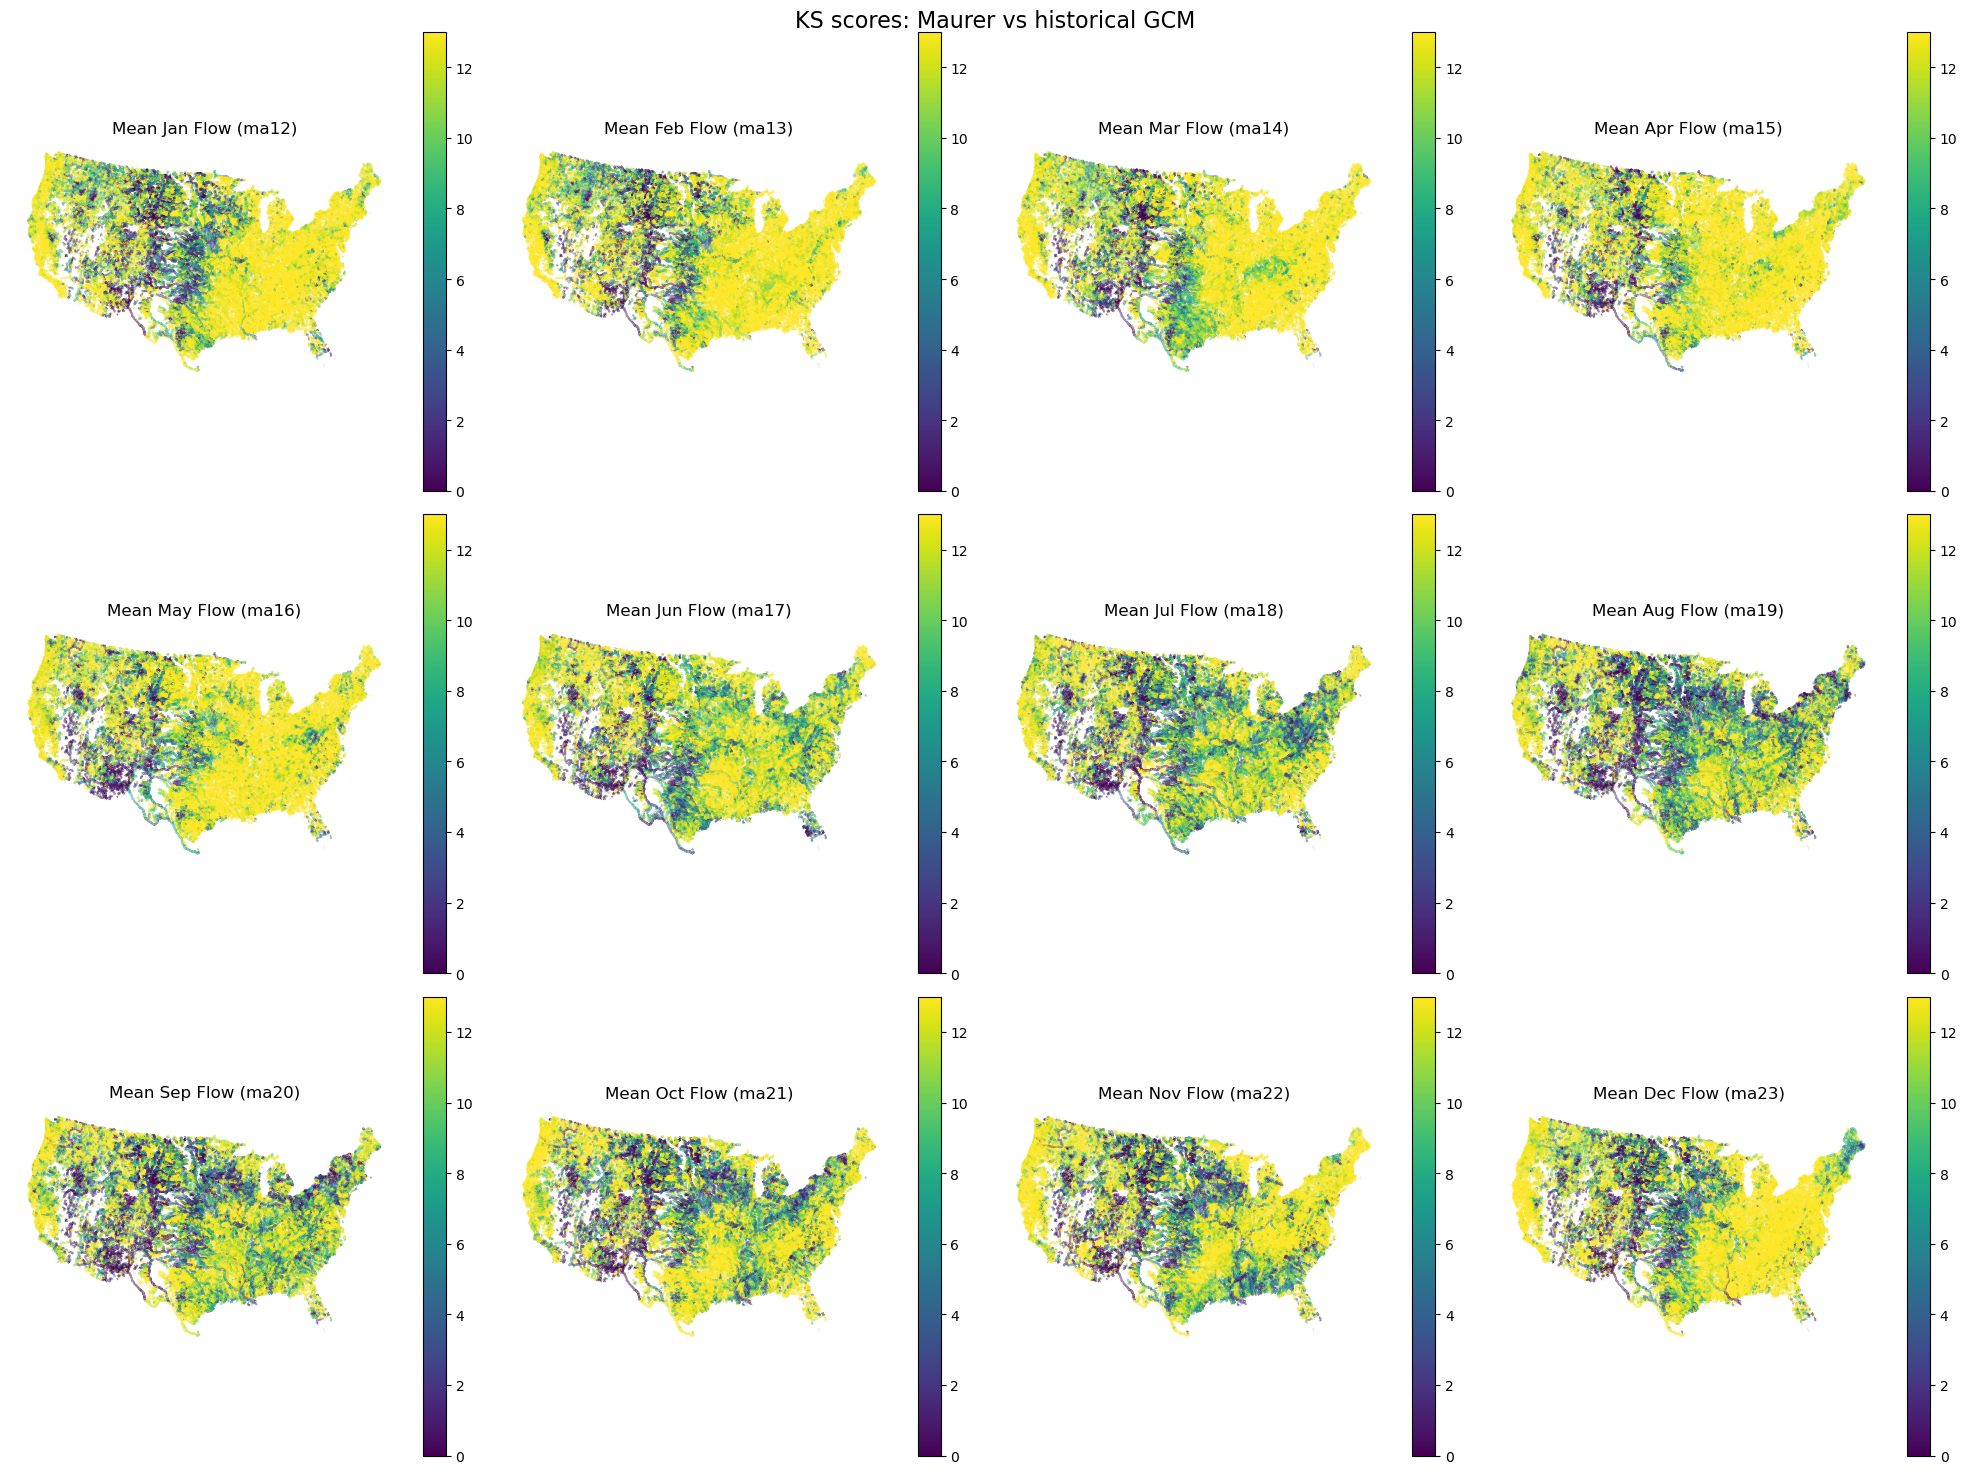

In [30]:
# small multiples plot of the KS scores for mean monthly flow stats

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
for i, stat in enumerate(stats):
    ax = axes[i // 4, i % 4]
    gdf.plot(column=stat, ax=ax, legend=True, cmap="viridis", vmin=0, vmax=13, alpha=0.5)
    ax.set_title(f"Mean {months[i]} Flow ({stat})")
    ax.set_axis_off()
fig.suptitle("KS scores: Maurer vs historical GCM", fontsize=16)
plt.tight_layout()
plt.show()

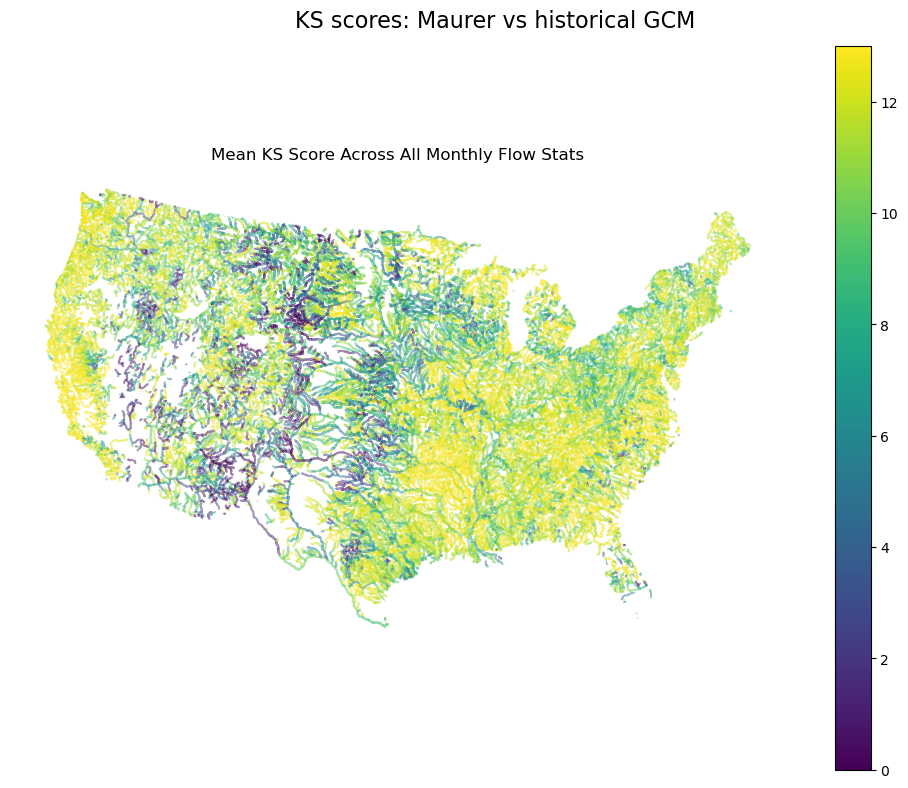

In [31]:
# calculate a mean KS score across all 12 monthly flow stats as a new column "KS_agg"
# plot it same as above but just 1 plot
gdf["KS_agg"] = gdf[stats].mean(axis=1)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column="KS_agg", ax=ax, legend=True, cmap="viridis", vmin=0, vmax=13, alpha=0.5)
ax.set_title(f"Mean KS Score Across All Monthly Flow Stats")
ax.set_axis_off()
fig.suptitle("KS scores: Maurer vs historical GCM", fontsize=16)
plt.tight_layout()
plt.show()


In [34]:
# gage performance
df_perf = pd.read_csv("./data_release/Stat_gage_performance_conus_new_1951_2009.csv", usecols=["seg_id", "SumScore"])
# join to gdf 
gdf_perf = seg.merge(df_perf, left_on="seg_id_nat", right_on="seg_id")

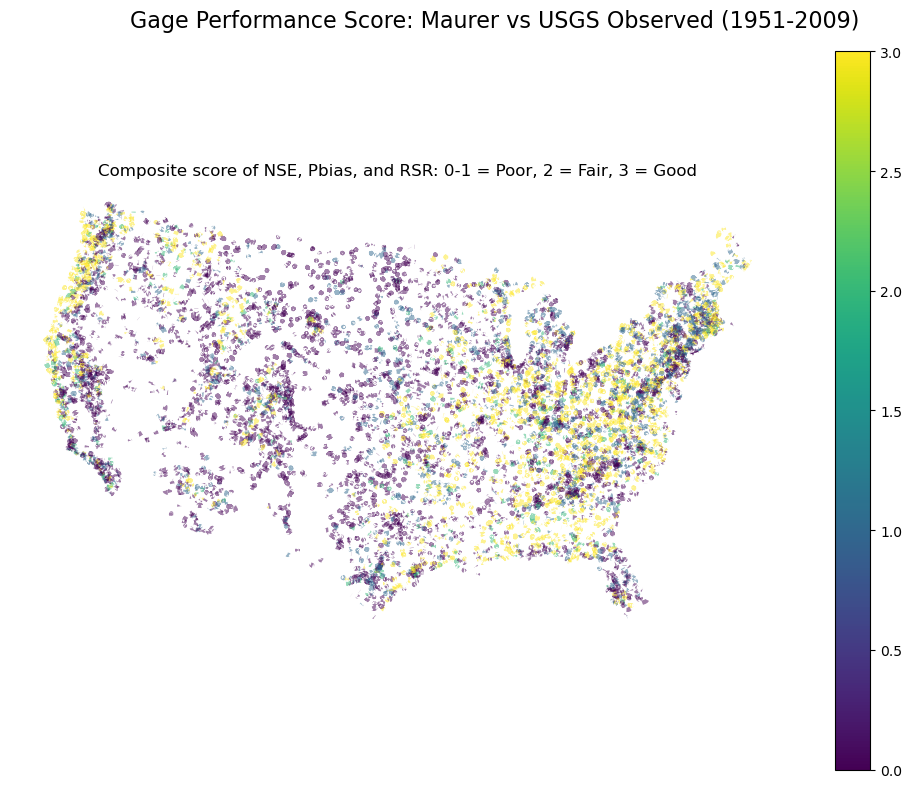

In [40]:
# plot gage performance
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf_perf.plot(column="SumScore", ax=ax, legend=True, cmap="viridis", vmin=0, vmax=3, alpha=0.5, linewidth=3)
ax.set_title(f"Composite score of NSE, Pbias, and RSR: 0-1 = Poor, 2 = Fair, 3 = Good")
ax.set_axis_off()
fig.suptitle("Gage Performance Score: Maurer vs USGS Observed (1951-2009)", fontsize=16)
plt.tight_layout()
plt.show()